In [4]:
import pandas as pd
import numpy as np
import openpyxl
import os
import re

# Data Proprocess

This notebook contains data process, include:

- School clasification, map undergraduate instituions
- Occupationclassification, map for job level and filed
- Age group, binned into 5 years group


- (Not used for now) How they met
- TODO: Graduate binary classification

# 1. School Classification

- standardizes and categorizes undergraduate institutions mentioned in wedding announcements into meaningful educational tiers based on U.S. rankings and reputation.

- We define four main categories:
  - **Ivy League**: Eight prestigious Northeastern universities.
  - **Top 50 Private (Non-Ivy)**: Highly-ranked private national universities outside the Ivy League.
  - **Top 50 Liberal Arts Colleges**: Selective liberal arts institutions focused on undergraduate education.
  - **Top 30 Public Universities**: Leading U.S. public research universities.

- To ensure consistent classification:
  - An alias mapping is used to standardize informal or abbreviated school names (e.g., "MIT" → "massachusetts institute of technology").
  - Schools mentioned in a combined field (e.g., “Harvard and MIT”) are split, normalized, and matched against known lists.
  - Priority is assigned by tier, with Ivy League > Top 50 Private > Top 30 Public > Other Colleges.

In [5]:
# Read the data
data = pd.read_excel("../data/2013-2023_update.xlsx")

In [64]:
school_cols = [col for col in data.columns if 'school' in col.lower()]

print(" Columns containing 'school':")
for col in school_cols:
    non_null = data[col].notnull().sum()
    unique = data[col].nunique()
    print(f"- {col:<45} | Non-null: {non_null:<4} | Unique: {unique}")


 Columns containing 'school':
- first_partner_undergraduate_school            | Non-null: 8445 | Unique: 1168
- first_partner_graduate_school                 | Non-null: 5551 | Unique: 1674
- first_partner_father_undergraduate_school     | Non-null: 443  | Unique: 43
- first_partner_father_graduate_school          | Non-null: 429  | Unique: 28
- first_partner_mother_undergraduate_school     | Non-null: 422  | Unique: 20
- first_partner_mother_graduate_school          | Non-null: 426  | Unique: 25
- second_partner_undergraduate_school           | Non-null: 8461 | Unique: 1371
- second_partner_graduate_school                | Non-null: 5070 | Unique: 1409
- second_partner_father_undergraduate_school    | Non-null: 424  | Unique: 22
- second_partner_father_graduate_school         | Non-null: 448  | Unique: 45
- second_partner_mother_undergraduate_school    | Non-null: 421  | Unique: 18
- second_partner_mother_graduate_school         | Non-null: 426  | Unique: 23


In [65]:
all_school_names = set()

for col in school_cols:
    uniques = data[col].dropna().unique()
    all_school_names.update([u.strip() for u in uniques if u.strip() != ""])

all_school_names = sorted(all_school_names)

# print(f"{len(all_school_names)} unique school names.\n")
# for name in all_school_names:
    # print(name)

In [66]:
data_demo = data[['first_partner_gender', 'first_partner_age','first_partner_undergraduate_school',
                  'second_partner_gender','second_partner_age','second_partner_undergraduate_school']].copy()


### School Mapping

In [67]:
# ========== 1. Ivy League ==========
ivy_league = {
    'harvard university', 'yale university', 'princeton university', 'columbia university',
    'university of pennsylvania', 'brown university', 'dartmouth college', 'cornell university'
}

# ========== 2. Top 50 Private (Non-Ivy) National Universities ==========
top_50_private = {
    'massachusetts institute of technology', 'stanford university', 'university of chicago',
    'california institute of technology', 'duke university', 'johns hopkins university',
    'northwestern university', 'vanderbilt university', 'rice university', 'washington university in st. louis',
    'university of notre dame', 'emory university', 'georgetown university', 'carnegie mellon university',
    'university of southern california', 'tufts university', 'new york university', 'boston college'
}

# ========== 3. Top 50 Liberal Arts Colleges ==========
top_50_liberal_arts = {
    'williams college', 'amherst college', 'swarthmore college', 'pomona college', 'wellesley college',
    'bowdoin college', 'carleton college', 'claremont mckenna college', 'middlebury college',
    'washington and lee university', 'smith college', 'grinnell college', 'haverford college',
    'davidson college', 'vassar college', 'hamilton college', 'colby college', 'bates college',
    'wesleyan university', 'barnard college'
}

# ========== 4. Top 30 Public Universities ==========
top_30_public = {
    'university of california los angeles', 'university of california berkeley', 'university of michigan',
    'university of north carolina chapel hill', 'university of virginia', 'university of florida',
    'university of california santa barbara', 'university of california san diego', 'university of california davis',
    'university of california irvine', 'university of wisconsin madison', 'university of illinois urbana champaign',
    'university of texas austin', 'georgia institute of technology', 'university of georgia',
    'ohio state university', 'university of washington', 'purdue university', 'university of maryland college park',
    'university of pittsburgh'
}

# ========== 5. Alias Mapping ==========
alias_map = {
    # Ivy League
    'brown': 'brown university',
    'columbia': 'columbia university',
    'princeton': 'princeton university',
    'harvard': 'harvard university',
    'yale': 'yale university',
    'dartmouth': 'dartmouth college',
    'cornell': 'cornell university',
    # National Universities
    'stanford': 'stanford university',
    'mit': 'massachusetts institute of technology',
    'm.i.t.': 'massachusetts institute of technology',
    'caltech': 'california institute of technology',
    'duke': 'duke university',
    'northwestern': 'northwestern university',
    'usc': 'university of southern california',
    'cmu': 'carnegie mellon university',
    'georgetown': 'georgetown university',
    'vanderbilt': 'vanderbilt university',
    'tufts': 'tufts university',
    'nyu': 'new york university',
    'n.y.u.': 'new york university',
    'washington university in st louis': 'washington university in st. louis',
    'notre dame': 'university of notre dame',
    # Liberal Arts
    'williams': 'williams college',
    'amherst': 'amherst college',
    'swarthmore': 'swarthmore college',
    'pomona': 'pomona college',
    'wellesley': 'wellesley college',
    'bowdoin': 'bowdoin college',
    'carleton': 'carleton college',
    'claremont mckenna': 'claremont mckenna college',
    'middlebury': 'middlebury college',
    'grinnell': 'grinnell college',
    'smith': 'smith college',
    'vassar': 'vassar college',
    'haverford': 'haverford college',
    'wesleyan': 'wesleyan university',
    'barnard': 'barnard college',
    # UC系统
    'uc berkeley': 'university of california berkeley',
    'ucla': 'university of california los angeles',
    'uc davis': 'university of california davis',
    'ucsd': 'university of california san diego',
    'uc irvine': 'university of california irvine',
    # Others
    'unc': 'university of north carolina chapel hill',
    'gpt-not found': ''
}



In [68]:
## Standardize the school names
def normalize_school_name(name):
    """
    Normalize the school name by removing extra spaces, converting to lowercase,
    and replacing common abbreviations with full names.
    """

    if pd.isna(name):
        return ""
    name = name.strip().lower()
    name = name.replace('.', '').replace(',', '')  # 去掉小数点和逗号
    if name in {'n/a', 'not provided', 'not mentioned', 'gpt-not found', ''}:
        return ""  # 归为 No College Mentioned
    return alias_map.get(name, name)


## Classify the school entry
def classify_school_combined(school_entry):
    """
    Classify the school entry into categories based on the provided lists.
    - checks for exact matches first, then fuzzy matches.
    - If no matches are found, it returns "No College Mentioned".
    - cases where the input is NaN or empty strings.
    - returns the highest priority category found in the input.
    """

    if pd.isna(school_entry) or str(school_entry).strip().lower() in {'n/a', 'not provided', 'not mentioned', 'gpt-not found', ''}:
        return "No College Mentioned"

    schools = re.split(r',| and |;', school_entry)
    categories = []
    
    for raw in schools:
        school = normalize_school_name(raw.strip())

        # Step 1: exact match
        if school in ivy_league:
            categories.append("Ivy League")
        elif school in top_50_private or school in top_50_liberal_arts:
            categories.append("Top 50 Private (Non-Ivy)")
        elif school in top_30_public:
            categories.append("Top 30 Public")
        else:
            # Step 2: fuzzy in match
            if any(iv in school for iv in ivy_league):
                categories.append("Ivy League")
            elif any(tp in school for tp in top_50_private.union(top_50_liberal_arts)):
                categories.append("Top 50 Private (Non-Ivy)")
            elif any(pub in school for pub in top_30_public):
                categories.append("Top 30 Public")
            else:
                categories.append("Other Colleges")

    # return based on the priority defined
    if "Ivy League" in categories:
        return "Ivy League"
    elif "Top 50 Private (Non-Ivy)" in categories:
        return "Top 50 Private (Non-Ivy)"
    elif "Top 30 Public" in categories:
        return "Top 30 Public"
    elif "Other Colleges" in categories:
        return "Other Colleges"
    else:
        return "No College Mentioned"


In [69]:
data_demo['first_partner_school_category'] = data_demo['first_partner_undergraduate_school'].apply(classify_school_combined)
data_demo['second_partner_school_category'] = data_demo['second_partner_undergraduate_school'].apply(classify_school_combined)

In [70]:
data_demo

,first_partner_gender,first_partner_age,first_partner_undergraduate_school,second_partner_gender,second_partner_age,second_partner_undergraduate_school,first_partner_school_category,second_partner_school_category
0,Female,31,Tufts,Male,32,Bowdoin College,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy)
1,Female,30,Yale,NaN,30,Yale,Ivy League,Ivy League
2,Female,28,George Washington University,Male,35,Washington University in St. Louis,Other Colleges,Top 50 Private (Non-Ivy)
3,Female,34,University of Florida,Male,43,University of Miami,Top 30 Public,Other Colleges
4,Female,27,Boston University,Male,33,University of Pennsylvania,Other Colleges,Ivy League
...,...,...,...,...,...,...,...,...
9154,Female,30,Wagner College,Male,31,Wagner College,Other Colleges,Other Colleges
9155,Female,42,Learning Institute of Beauty Sciences,Female,50,Bowling Green State University,Other Colleges,Other Colleges
9156,Male,31,Georgetown,Female,33,Northwestern,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy)
9157,Female,46,Michigan State University,Male,42,Lane College,Other Colleges,Other Colleges


In [71]:
# Sample 50 rows for checking
sample_check = data_demo[['first_partner_undergraduate_school', 'first_partner_school_category']].sample(50, random_state=42)
print(sample_check.to_string(index=False))

     first_partner_undergraduate_school first_partner_school_category
            City University of New York                Other Colleges
                       Oberlin College;                Other Colleges
               Miami University in Ohio                Other Colleges
               Parsons School of Design                Other Colleges
                        Rice University      Top 50 Private (Non-Ivy)
                   Villanova University                Other Colleges
                                    NaN          No College Mentioned
                                 N.Y.U.      Top 50 Private (Non-Ivy)
                                  Tufts      Top 50 Private (Non-Ivy)
                Old Dominion University                Other Colleges
                        Yale University                    Ivy League
                  Georgetown University      Top 50 Private (Non-Ivy)
                    New York University      Top 50 Private (Non-Ivy)
                    

In [72]:
"""
for cat in ['Ivy League', 'Top 50 Private (Non-Ivy)', 'Top 30 Public', 'Other Colleges', 'No College Mentioned']:
    subset = data_demo[data_demo['first_partner_school_category'] == cat]
    print(f"\nTop 10 schools in category '{cat}':")
    print(subset['first_partner_undergraduate_school'].value_counts().head(10))
"""

'\nfor cat in [\'Ivy League\', \'Top 50 Private (Non-Ivy)\', \'Top 30 Public\', \'Other Colleges\', \'No College Mentioned\']:\n    subset = data_demo[data_demo[\'first_partner_school_category\'] == cat]\n    print(f"\nTop 10 schools in category \'{cat}\':")\n    print(subset[\'first_partner_undergraduate_school\'].value_counts().head(10))\n'

# 2. Occupation classification

- See more details in the occ_preprocess
- Initial Occupation extraction was done through GPT API
- This section clean the results and map the lists


In [73]:
occupation_cols = [col for col in data.columns if 'occupation' in col.lower()]

print(" Columns containing 'occupation':")
for col in occupation_cols:
    non_null = data[col].notnull().sum()
    unique = data[col].nunique()
    print(f"- {col:<45} | Non-null: {non_null:<4} | Unique: {unique}")


 Columns containing 'occupation':
- first_partner_occupation                      | Non-null: 8767 | Unique: 5781
- first_partner_father_occupation               | Non-null: 5740 | Unique: 4127
- first_partner_mother_occupation               | Non-null: 4959 | Unique: 3356
- second_partner_occupation                     | Non-null: 8944 | Unique: 6152
- second_partner_father_occupation              | Non-null: 5876 | Unique: 4140
- second_partner_mother_occupation              | Non-null: 4905 | Unique: 3205


In [74]:
all_occupation_names = set()

for col in occupation_cols:
    uniques = data[col].dropna().unique()
    all_occupation_names.update([u.strip() for u in uniques if u.strip() != ""])

all_occupation_names = sorted(all_occupation_names)

#print(f"{len(all_occupation_names)} occupations .\n")
#for name in all_occupation_names:
    #print(name)

In [75]:
def classify_job_level(occupation):
    """
    Classify job level based on keywords in the occupation string.

    The standard is from Linkedin Job Level.
    https://www.linkedin.com/pulse/linkedin-experience-levels-bry-willis/
    
    Job levels are categorized as:
    - Executive
    - Senior
    - Mid
    - Entry
    - Other
    """
    if pd.isna(occupation) or str(occupation).strip() == "":
        return "Other"
    
    occ = str(occupation).lower()
    if any(keyword in occ for keyword in ['chief', 'ceo', 'cfo', 'coo', 'president', 'founder', 'managing director']):
        return 'Executive'
    elif any(keyword in occ for keyword in ['senior', 'director', 'partner', 'lead', 'principal', 'vice president']):
        return 'Senior'
    elif any(keyword in occ for keyword in ['manager', 'engineer', 'specialist', 'architect', 'designer', 'scientist', 'teacher', 'professor']):
        return 'Mid'
    elif any(keyword in occ for keyword in ['assistant', 'associate', 'intern', 'analyst', 'aide', 'clerk', 'coordinator', 'technician']):
        return 'Entry'
    else:
        return 'Other'

def classify_job_field(occupation):
    """
    Classify job field based on keywords in the occupation string.
    """
    if pd.isna(occupation) or str(occupation).strip() == "":
        return "Other/Unknown"
    
    occ = str(occupation).lower()
    if any(keyword in occ for keyword in ['finance', 'banker', 'accountant', 'financial', 'investment', 'analyst', 'trader']):
        return 'Finance/Business'
    elif any(keyword in occ for keyword in ['lawyer', 'attorney', 'legal', 'counsel', 'paralegal', 'judge']):
        return 'Law'
    elif any(keyword in occ for keyword in ['teacher', 'professor', 'instructor', 'educator', 'academic']):
        return 'Education'
    elif any(keyword in occ for keyword in ['physician', 'doctor', 'nurse', 'therapist', 'psychiatrist', 'surgeon', 'pharmacist']):
        return 'Healthcare'
    elif any(keyword in occ for keyword in ['engineer', 'developer', 'programmer', 'scientist', 'data scientist']):
        return 'Engineering/Tech'
    elif any(keyword in occ for keyword in ['artist', 'designer', 'photographer', 'actor', 'musician', 'editor', 'writer', 'journalist']):
        return 'Arts/Media'
    elif any(keyword in occ for keyword in ['officer', 'agent', 'politician', 'senator', 'mayor', 'diplomat']):
        return 'Government/Public Service'
    elif any(keyword in occ for keyword in ['marketing', 'sales', 'advertiser', 'representative', 'merchandiser']):
        return 'Sales/Marketing'
    elif any(keyword in occ for keyword in ['realtor', 'real estate', 'builder', 'contractor']):
        return 'Real Estate/Construction'
    elif any(keyword in occ for keyword in ['consultant', 'adviser', 'strategist']):
        return 'Consulting'
    else:
        return 'Other/Unknown'

def detect_retired(occupation):
    """
    Detect if the occupation indicates that the person is retired.
    Returns 1 if retired, 0 otherwise.
    """
    if pd.isna(occupation) or str(occupation).strip() == "":
        return 0
    
    occ = str(occupation).lower()
    if 'retired' in occ:
        return 1
    else:
        return 0

In [76]:
# classify based on the occupation names
# and then create a mapping dictionary

unique_occupations_df = pd.DataFrame({'occupation': all_occupation_names})

unique_occupations_df['job_level'] = unique_occupations_df['occupation'].apply(classify_job_level)
unique_occupations_df['job_field'] = unique_occupations_df['occupation'].apply(classify_job_field)
unique_occupations_df['is_retired'] = unique_occupations_df['occupation'].apply(detect_retired)

occupation_mapping = unique_occupations_df.set_index('occupation')[['job_level', 'job_field', 'is_retired']].to_dict(orient='index')

# Apply and return the orignal ddf data

for col in occupation_cols:
    data[f'{col}_level'] = data[col].apply(lambda x: occupation_mapping.get(x.strip(), {'job_level': 'Other'})['job_level'] if pd.notna(x) and x.strip() != "" else 'Other')
    data[f'{col}_field'] = data[col].apply(lambda x: occupation_mapping.get(x.strip(), {'job_field': 'Other/Unknown'})['job_field'] if pd.notna(x) and x.strip() != "" else 'Other/Unknown')
    data[f'{col}_retired'] = data[col].apply(lambda x: occupation_mapping.get(x.strip(), {'is_retired': 0})['is_retired'] if pd.notna(x) and x.strip() != "" else 0)


In [77]:
data[[c for c in data.columns if any(key in c for key in ['occupation', 'level', 'field', 'retired'])]].head()

,first_partner_occupation,first_partner_father_occupation,first_partner_mother_occupation,second_partner_occupation,second_partner_father_occupation,second_partner_mother_occupation,first_partner_level_id,first_partner_father_level_id,first_partner_mother_level_id,second_partner_level_id,...,first_partner_mother_occupation_retired,second_partner_occupation_level,second_partner_occupation_field,second_partner_occupation_retired,second_partner_father_occupation_level,second_partner_father_occupation_field,second_partner_father_occupation_retired,second_partner_mother_occupation_level,second_partner_mother_occupation_field,second_partner_mother_occupation_retired
0,Architectural designer,Surgical oncologist and medical director,Adjunct assistant professor of public health,NaN,Real estate investment,Pediatric physical therapist,S4,S5,S4,NaN,...,0,Other,Other/Unknown,0,Other,Finance/Business,0,Other,Healthcare,0
1,Director for operations,Leadership development consultant,Retired family and consumer science teacher,Founder of Farm Hill,Internist,Women’s health nurse practitioner,S5,S4,S1,S5,...,1,Executive,Other/Unknown,0,Entry,Other/Unknown,0,Other,Healthcare,0
2,Independent Consultant,NaN,NaN,Oral and Maxillofacial Surgeon,Internist,NaN,S4,NaN,NaN,S5,...,0,Other,Healthcare,0,Entry,Other/Unknown,0,Other,Other/Unknown,0
3,Vice President,NaN,NaN,Agent,NaN,NaN,S5,NaN,NaN,S3,...,0,Other,Government/Public Service,0,Other,Other/Unknown,0,Other,Other/Unknown,0
4,Owner of an interior design company,Retired marketing director,NaN,Manager in the private client group at Fisher ...,President of Adcole Corporation,Reading specialist at Brimmer and May School,S5,S6,NaN,S4,...,0,Mid,Finance/Business,0,Executive,Other/Unknown,0,Mid,Other/Unknown,0


# 3. Age -> Age Group

- Binned age into groups for every 5 years
- Fix abnormal data found 

In [78]:
data_demo['first_partner_age'].unique()
# data_demo['second_partner_age'].unique()

array(['31', '30', '28', '34', '27', '35', '36', '48', 'Not mentioned',
       '32', '45', '22', '24', '25', '50', '29', '26', '33', '55', '56',
       '38', '23', '37', '42', '47', '49', '53', '75', '43', '72', '51',
       '61', '67', '76', '58', '52', '41', '54', '44', '46', '39', '69',
       '40', '57', '74', '62', '59', '63', '66', '64', '70', '60', '81',
       '65', '68', 'GPT-not found', '83', '20', '71', '73', '80', '19',
       '21', '82', '12', '79', '85', '3431', '89', '78', '77'],
      dtype=object)

## fix abnormal data

In [79]:
idx = data_demo.index[data_demo['first_partner_age'] == '3431']
print(idx)
data_demo.loc[data_demo['first_partner_age'] == '3431', ['first_partner_age', 'second_partner_age', 'first_partner_gender', 'second_partner_gender']] = [34, 31, 'female', 'female']
data_demo.loc[idx]
# jessica fields 34, sensening 31 

Index([8693], dtype='int64')


,first_partner_gender,first_partner_age,first_partner_undergraduate_school,second_partner_gender,second_partner_age,second_partner_undergraduate_school,first_partner_school_category,second_partner_school_category
8693,female,34,Dr. Jessica Chaplin Fields graduated magna cum...,female,31,NaN,Other Colleges,No College Mentioned


In [80]:
# 12 and 14 when first met
idx = data_demo.index[data_demo['first_partner_age'] == '12']
print(idx)
data_demo.loc[idx, ['first_partner_age', 'second_partner_age']] = [30, 33]
data_demo.loc[idx]

Index([7757], dtype='int64')


,first_partner_gender,first_partner_age,first_partner_undergraduate_school,second_partner_gender,second_partner_age,second_partner_undergraduate_school,first_partner_school_category,second_partner_school_category
7757,Female,30,University of Georgia,Male,33,University of Georgia,Top 30 Public,Top 30 Public


In [81]:
# delete 2930 and 2827, contains multiple couple information
print(data_demo[data_demo['second_partner_age'].isin(['2930', '2827'])])
data_demo = data_demo[~data_demo['second_partner_age'].isin(['2930', '2827'])]
#data_demo

                                   first_partner_gender first_partner_age  \
3681  Irene Morgenshtern: Female; Raymond Wai Lin: Male     Not mentioned   
4592     Corina Biton - Female; Gary Blicksilver - Male     Not mentioned   

                     first_partner_undergraduate_school  \
3681  Irene Morgenshtern: not provided; Raymond Wai ...   
4592                                University of Miami   

                                  second_partner_gender second_partner_age  \
3681    Krista Elise Zegura: Female; Adam Sowlati: Male               2930   
4592  Shaina Roet Watrous - Female; Joseph Walzer Ba...               2827   

                    second_partner_undergraduate_school  \
3681  Krista Elise Zegura: Stanford University; Adam...   
4592  Shaina Roet Watrous - N.Y.U.; Joseph Walzer Ba...   

     first_partner_school_category second_partner_school_category  
3681                Other Colleges       Top 50 Private (Non-Ivy)  
4592                Other Colleges       

In [82]:
bins = [25, 30, 35, 40, 45]
labels = ['25-29', '30-34', '35-39', '40-44']

# age to number, not mentioned to NaN
first_age_numeric = pd.to_numeric(data_demo['first_partner_age'], errors='coerce')
second_age_numeric = pd.to_numeric(data_demo['second_partner_age'], errors='coerce')

# bin 
data_demo['first_partner_age_bin'] = pd.cut(first_age_numeric, bins=bins, labels=labels, right=False)
data_demo['second_partner_age_bin'] = pd.cut(second_age_numeric, bins=bins, labels=labels, right=False)

# NaN --> 'Unknown'
data_demo['first_partner_age_bin'] = data_demo['first_partner_age_bin'].cat.add_categories('Unknown').fillna('Unknown')
data_demo['second_partner_age_bin'] = data_demo['second_partner_age_bin'].cat.add_categories('Unknown').fillna('Unknown')

data_demo


/var/folders/nq/b05k17xs7411cy3jwjmjn1rm0000gn/T/ipykernel_72631/102015838.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_demo['first_partner_age_bin'] = pd.cut(first_age_numeric, bins=bins, labels=labels, right=False)
/var/folders/nq/b05k17xs7411cy3jwjmjn1rm0000gn/T/ipykernel_72631/102015838.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_demo['second_partner_age_bin'] = pd.cut(second_age_numeric, bins=bins, labels=labels, right=False)
/var/folders/nq/b05k17xs7411cy3jwjmjn1rm0000gn/T/ip

,first_partner_gender,first_partner_age,first_partner_undergraduate_school,second_partner_gender,second_partner_age,second_partner_undergraduate_school,first_partner_school_category,second_partner_school_category,first_partner_age_bin,second_partner_age_bin
0,Female,31,Tufts,Male,32,Bowdoin College,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy),30-34,30-34
1,Female,30,Yale,NaN,30,Yale,Ivy League,Ivy League,30-34,30-34
2,Female,28,George Washington University,Male,35,Washington University in St. Louis,Other Colleges,Top 50 Private (Non-Ivy),25-29,35-39
3,Female,34,University of Florida,Male,43,University of Miami,Top 30 Public,Other Colleges,30-34,40-44
4,Female,27,Boston University,Male,33,University of Pennsylvania,Other Colleges,Ivy League,25-29,30-34
...,...,...,...,...,...,...,...,...,...,...
9154,Female,30,Wagner College,Male,31,Wagner College,Other Colleges,Other Colleges,30-34,30-34
9155,Female,42,Learning Institute of Beauty Sciences,Female,50,Bowling Green State University,Other Colleges,Other Colleges,40-44,Unknown
9156,Male,31,Georgetown,Female,33,Northwestern,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy),30-34,30-34
9157,Female,46,Michigan State University,Male,42,Lane College,Other Colleges,Other Colleges,Unknown,40-44


# how_first_met classification

In [83]:
# how_first_met
#data['how_first_met']

In [84]:
how_first_met_data = data['how_first_met']

missing_count = how_first_met_data.isna().sum()

unique_values = how_first_met_data.dropna().unique()

num_unique = len(unique_values)

missing_count, num_unique, unique_values[:20] 

(2498,
 5013,
 array(['Met at Harvard', 'They met at Yale.',
        'They first met at a party held by mutual friends on Cape Cod.',
        'On the dating website Match.com', 'Not mentioned',
        'They played together as babies and met again as adults at the wedding of the groom’s brother.',
        'On the matchmaking site JDate', 'At a bar in Manhattan',
        'Both received a law degree from Georgetown.',
        'Playing charades at a games night',
        'At Johns Hopkins where they graduated from',
        'Met at Villanova University', 'They met at Muhlenberg College.',
        'At a dinner party in Manhattan thrown by mutual friends.',
        'They met in Rome during a semester abroad',
        'They met at the Bourgeois Pig, a restaurant in the East Village.',
        'Met at Brown', 'High school students',
        'At a birthday party for a mutual friend.',
        'At a wedding in Los Angeles in 2013'], dtype=object))

In [85]:
def first_pass_classification(text):
    if pd.isna(text) or 'not mentioned' in str(text).lower():
        return 'Other'
    text = str(text).lower()
    if any(keyword in text for keyword in ['work', 'school', 'university', 'college', 'graduate',
                                           'harvard', 'yale', 'princeton', 'stanford', 'columbia', 
                                           'brown', 'uchicago', 'dartmouth', 'cornell', 'upenn', 'mit',
                                           'northwestern', 'duke', 'georgetown', 'nyu', 'bu']):
        return 'Work or School'
    elif any(keyword in text for keyword in ['bar', 'party', 'restaurant', 'event', 'wedding', 'concert', 'games night']):
        return 'Bar/Sport/Events'
    elif any(keyword in text for keyword in ['friend', 'family', 'church', 'blind date']):
        return 'Friends/Family/Church'
    elif any(keyword in text for keyword in ['match.com', 'bumble', 'jdate', 'tinder', 'dating app', 'online']):
        return 'Dating Apps Online'
    else:
        return 'Other'

data['how_first_met_category'] = data['how_first_met'].apply(first_pass_classification)

how_met_summary = data['how_first_met_category'].value_counts(dropna=False).reset_index()
how_met_summary.columns = ['Category', 'Count']
how_met_summary['Percentage'] = (how_met_summary['Count'] / how_met_summary['Count'].sum() * 100).round(2)

print(how_met_summary)

                Category  Count  Percentage
0                  Other   4144       45.25
1         Work or School   2468       26.95
2       Bar/Sport/Events    915        9.99
3  Friends/Family/Church    838        9.15
4     Dating Apps Online    794        8.67


In [86]:
from collections import Counter
import re

# Top 100 words in Other category
other_texts = data[data['how_first_met_category'] == 'Other']['how_first_met'].dropna()

words = []
for text in other_texts:
    tokens = re.findall(r'\b\w+\b', str(text).lower())
    words.extend(tokens)

word_counts = Counter(words)
common_words = word_counts.most_common(100)

print("Top 100 words in Other category：")
for word, count in common_words:
    print(f"{word}: {count}")


Top 100 words in Other category：
in: 737
the: 725
a: 691
at: 606
met: 485
they: 478
on: 297
through: 287
and: 222
okcupid: 219
of: 210
to: 201
for: 173
s: 171
not: 159
was: 155
new: 124
by: 111
york: 102
mr: 100
an: 92
first: 89
as: 89
their: 88
where: 87
during: 86
dating: 86
found: 84
while: 83
gpt: 81
introduced: 74
ms: 73
mentioned: 64
were: 63
groom: 62
bride: 60
her: 59
with: 53
when: 53
each: 51
couple: 50
other: 49
after: 49
website: 48
washington: 44
both: 44
his: 43
n: 37
manhattan: 36
club: 34
summer: 34
up: 33
she: 33
asked: 31
y: 30
who: 30
he: 30
over: 29
group: 28
2013: 28
2012: 27
him: 27
that: 27
from: 27
trip: 25
law: 25
had: 25
out: 25
san: 24
medical: 24
date: 24
program: 24
conference: 24
site: 24
dinner: 23
dr: 23
u: 22
meeting: 22
coffee: 22
connected: 22
fund: 21
later: 21
center: 21
sister: 21
reconnected: 20
camp: 20
together: 19
city: 19
facebook: 19
interns: 19
2014: 19
2015: 19
day: 18
mutual: 18
game: 18
team: 18
class: 18
conversation: 18
festival: 18
pla

In [87]:
# club -> Bar/Sport/Events
# okcupid -> Dating Apps Online 
# manhattan: 36 -> Not sure
# introduced -> Not sure
# 有wedding、party、club、manhattan ➡️ 归到 Bar/Sport/Events

manhattan_samples = data[data['how_first_met'].str.contains('manhattan', case=False, na=False)]

num_manhattan = manhattan_samples.shape[0]

sample_texts = manhattan_samples['how_first_met'].sample(20, random_state=42).tolist()

num_manhattan, sample_texts

# 单独出现"Manhattan"不足以推断是学校，
#但如果文本里同时出现"work"、"school"、"training"、"college"、"university"这样的词，才能归到Work or School

(191,
 ['They matched on Tinder and met in person at a bar in Manhattan.',
  'They met at a Latin dance party in Manhattan.',
  'They met at a bar in Manhattan when Rafe noticed Michael and decided to stay for a drink.',
  'At a get-together in Manhattan of mutual friends',
  'At a Halloween party in Manhattan',
  'Through mutual friends in 2012 at a bar in Manhattan',
  'They met at a karaoke party in Koreatown in Manhattan.',
  'Working at Borderfree, an e-commerce firm in Manhattan',
  'The couple met in an elevator at the MetLife building in Manhattan.',
  'They met in 2012 while in medical training at the New York Eye and Ear Infirmary in Manhattan.',
  'Ms. Netzer was an instructor and Mr. Knowles was a student at Greenwich House Pottery in Manhattan.',
  'They matched on Tinder and met in person at a gin bar in Manhattan.',
  'They met at Hunter College High School in Manhattan.',
  'They first met at a party in Los Angeles where Kelly was engaged. They crossed paths again in Ma

In [88]:
def second_pass_other_final_updated(text):
    if pd.isna(text):
        return 'Other'
    
    text = str(text).lower()
    
    # 1. Dating Apps Online
    if any(keyword in text for keyword in ['okcupid', 'bumble', 'tinder', 'match.com', 'dating app', 'website', 'online', 'jdate', 'eharmony', 'facebook']):
        return 'Dating Apps Online'
    
    # 2. Bar/Sport/Events
    elif any(keyword in text for keyword in ['wedding', 'groom', 'bride', 'party', 'bar', 'club', 'restaurant', 'event', 'lounge', 'concert', 'gym', 'trip', 'festival', 'conference']):
        return 'Bar/Sport/Events'
    
    # 3. Friends/Family/Church
    elif 'introduced' in text:
        # Introduced + dating app -> Dating Apps Online
        if any(keyword in text for keyword in ['okcupid', 'bumble', 'tinder', 'match.com', 'dating app', 'website', 'online', 'jdate', 'eharmony', 'facebook']):
            return 'Dating Apps Online'
        else:
            return 'Friends/Family/Church'
    elif any(keyword in text for keyword in ['friend', 'family', 'church', 'blind date', 'mutual']):
        return 'Friends/Family/Church'
    
    # 4. Work or School
    elif any(keyword in text for keyword in ['school', 'college', 'university', 'graduate',
                                             'harvard', 'yale', 'princeton', 'stanford', 'columbia',
                                             'brown', 'dartmouth', 'cornell', 'upenn', 'mit',
                                             'northwestern', 'duke', 'georgetown', 'nyu', 'bu', 'studying']):
        return 'Work or School'
    
    # 5. Special Handling for "washington"
    elif 'washington' in text:
        if any(edu in text for edu in ['school', 'university', 'college', 'graduate']):
            return 'Work or School'
        else:
            return 'Bar/Sport/Events'
    
    # 6. Special Handling for "new york"
    elif 'new york' in text:
        if any(event in text for event in ['party', 'bar', 'restaurant', 'event', 'club']):
            return 'Bar/Sport/Events'
        else:
            return 'Other'
    
    else:
        return 'Other'

other_mask = data['how_first_met_category'] == 'Other'
data.loc[other_mask, 'how_first_met_category'] = data.loc[other_mask, 'how_first_met'].apply(second_pass_other_final_updated)

how_met_summary_final = data['how_first_met_category'].value_counts(dropna=False).reset_index()
how_met_summary_final.columns = ['Category', 'Count']
how_met_summary_final['Percentage'] = (how_met_summary_final['Count'] / how_met_summary_final['Count'].sum() * 100).round(2)

print("Final how_first_met_category after updated second pass cleaning:")
print(how_met_summary_final)


Final how_first_met_category after updated second pass cleaning:
                Category  Count  Percentage
0                  Other   3560       38.87
1         Work or School   2481       27.09
2       Bar/Sport/Events   1156       12.62
3     Dating Apps Online   1070       11.68
4  Friends/Family/Church    892        9.74


### Final Preprocessing Methodology for "how_first_met" Field

#### First Pass Cleaning
- Conducted keyword-based classification into five major categories:
  - Work or School
  - Bar/Sport/Events
  - Friends/Family/Church
  - Dating Apps Online
  - Other (uncategorized)

#### Second Pass Cleaning (Keyword-Based Refinement)
- Performed exploratory analysis (EDA) on the top 50 and later the top 100 most frequent words within the "Other" category.
- Designed additional fine-grained keyword rules based on the EDA findings:
  - **okcupid, bumble, tinder, match.com, dating app, website, online, jdate, eharmony, facebook** → Classified as **Dating Apps Online**
  - **wedding, groom, bride, party, bar, club, restaurant, event, lounge, concert, gym, trip, festival, conference** → Classified as **Bar/Sport/Events**
  - **friend, mutual friend, family, church, blind date, introduced** → Classified as **Friends/Family/Church** (with caution: introduced combined with dating apps classified into Dating Apps Online)
  - **school, college, university, graduate, studying** and famous university names → Classified as **Work or School**
  - **washington** → Context-dependent: with education keywords → Work or School, otherwise → Bar/Sport/Events
  - **new york** → Context-dependent: with event-related keywords → Bar/Sport/Events

- Special handling for ambiguous cases like "Manhattan", "Introduced", and "Washington" was incorporated with cautious context checking.

Through iterative secondary cleaning and careful EDA, we successfully refined the `how_first_met` field,  reducing the "Other" category from over 50% to approximately 38%.   This greatly improved the feature's quality, structure, and usefulness for model training,  while maintaining a balance between data cleaning efficiency and modeling robustness.


# Merge data 

- Merge the preprocessed columns into final desired order.

In [89]:
data_demo.columns

Index(['first_partner_gender', 'first_partner_age',
       'first_partner_undergraduate_school', 'second_partner_gender',
       'second_partner_age', 'second_partner_undergraduate_school',
       'first_partner_school_category', 'second_partner_school_category',
       'first_partner_age_bin', 'second_partner_age_bin'],
      dtype='object')

In [90]:
# Desired final column order
final_column_order = [
    'url',
    'filename',
    'first_partner_gender',
    'first_partner_age_bin',
    'second_partner_gender',
    'second_partner_age_bin',
    'first_partner_school_category',
    'second_partner_school_category',
    'first_partner_level_id',
    'second_partner_level_id',
    'first_partner_field',
    'second_partner_field'
]

# Ensure all required columns exist: use from data if missing from data_demo
for col in final_column_order:
    if col not in data_demo.columns:
        data_demo[col] = data[col]

# Reorder columns to match the desired final layout
data_final = data_demo[final_column_order]

/var/folders/nq/b05k17xs7411cy3jwjmjn1rm0000gn/T/ipykernel_72631/1477867321.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_demo[col] = data[col]
/var/folders/nq/b05k17xs7411cy3jwjmjn1rm0000gn/T/ipykernel_72631/1477867321.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_demo[col] = data[col]
/var/folders/nq/b05k17xs7411cy3jwjmjn1rm0000gn/T/ipykernel_72631/1477867321.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [93]:
data_final

,url,filename,first_partner_gender,first_partner_age_bin,second_partner_gender,second_partner_age_bin,first_partner_school_category,second_partner_school_category,first_partner_level_id,second_partner_level_id,first_partner_field,second_partner_field
0,https://www.nytimes.com/2015/01/11/fashion/wed...,f657c24a-6a56-5ca4-b97f-088c31f8e0bb,Female,30-34,Male,30-34,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy),S4,NaN,Architecture and Engineering Occupations,NaN
1,https://www.nytimes.com/2015/08/02/fashion/wed...,def8fbc6-6199-520e-be42-42ecf6f1a26b,Female,30-34,NaN,30-34,Ivy League,Ivy League,S5,S5,Management Occupations,Architecture and Engineering Occupations
2,https://www.nytimes.com/2015/06/14/fashion/wed...,1e99518c-5fe6-59a2-a4a6-9b9d91afcf3b,Female,25-29,Male,35-39,Other Colleges,Top 50 Private (Non-Ivy),S4,S5,Healthcare Occupations,Healthcare Occupations
3,https://www.nytimes.com/2015/02/22/fashion/wed...,6cf6a025-0b2b-5d90-b51f-660af4435824,Female,30-34,Male,40-44,Top 30 Public,Other Colleges,S5,S3,Management Occupations,Sales Occupations
4,https://www.nytimes.com/2015/09/13/fashion/wed...,02e3808c-b94f-5635-84c6-71d9ab1e47ea,Female,25-29,Male,30-34,Other Colleges,Ivy League,S5,S4,Arts and Design Occupations,Management Occupations
...,...,...,...,...,...,...,...,...,...,...,...,...
9154,https://www.nytimes.com/article/postpartum-exe...,3c27d6d3-e6c5-5467-8542-f36230b1d309,Female,30-34,Male,30-34,Other Colleges,Other Colleges,S4,S4,Business and Financial Occupations,Computer and Information Technology Occupations
9155,https://www.nytimes.com/2019/11/15/nyregion/ho...,4f40a40a-233a-5b50-abf6-ea79150a768c,Female,40-44,Female,Unknown,Other Colleges,Other Colleges,S1,S4,Entertainment and Sports Occupations,Business and Financial Occupations
9156,https://www.nytimes.com/2023/07/14/arts/music/...,824bbba1-91d6-5445-81e5-3dacb4227029,Male,30-34,Female,30-34,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy),S5,S4,Management Occupations,Legal Occupations
9157,https://www.nytimes.com/interactive/2023/04/14...,07d469af-2988-5b51-813d-c408a1413408,Female,Unknown,Male,40-44,Other Colleges,Other Colleges,S4,S4,Media and Communication Occupations,"Life, Physical, and Social Science Occupations"


In [94]:
# Save
data_final.to_excel('../Data/data_final.xlsx', index=False)


# Graduate Binary Classification

In [6]:
# Read the data
data = pd.read_excel("../data/2013-2023_update.xlsx")

In [9]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_df = pd.read_excel("../data/2013-2023_update.xlsx", sheet_name="Sheet1")

# Handle missing values in 'second_partner_graduate_school' 
raw_df['second_partner_graduate_school'] = raw_df['second_partner_graduate_school'].fillna('Not mentioned')

# Define a function to classify the graduate school
def is_graduate(x):
    x = str(x).strip().lower()
    exact_exclude = ['not mentioned', 'gpt-not found', 'not provided', 'na', 'none', 'no info']
    return 0 if x in exact_exclude else 1

raw_df['second_partner_is_graduate'] = raw_df['second_partner_graduate_school'].apply(is_graduate)


In [18]:
raw_df['second_partner_is_graduate'].value_counts()

second_partner_is_graduate
1    4903
0    4256
Name: count, dtype: int64

In [19]:
raw_df[raw_df['second_partner_is_graduate'] == 1]['second_partner_graduate_school'].sample(10)

3644                          University of Toledo
3506                                        Oxford
1630           University of California, San Diego
4223                            Suffolk University
3869                        Wayne State University
1124                           University of Miami
2506                                      Stanford
6777                            Harvard University
6763                                      Stanford
7566    Rutgers-Robert Wood Johnson Medical School
Name: second_partner_graduate_school, dtype: object

In [22]:
raw_df[raw_df['second_partner_is_graduate'] == 0]['second_partner_graduate_school'].sample(10)

5617    Not mentioned
372     Not mentioned
6074    Not mentioned
5504    Not mentioned
6805    Not mentioned
6157    Not mentioned
4505    Not mentioned
3442    Not mentioned
3448    Not mentioned
2200    Not mentioned
Name: second_partner_graduate_school, dtype: object

In [26]:
raw_df[raw_df['second_partner_is_graduate'] == 0]['second_partner_graduate_school'].value_counts()

second_partner_graduate_school
Not mentioned    4194
GPT-not found      62
Name: count, dtype: int64

/var/folders/z1/qgjtgd396xq6w1n2txl607c00000gn/T/ipykernel_44174/3850539725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_df, x='second_partner_is_graduate', palette='Set2')


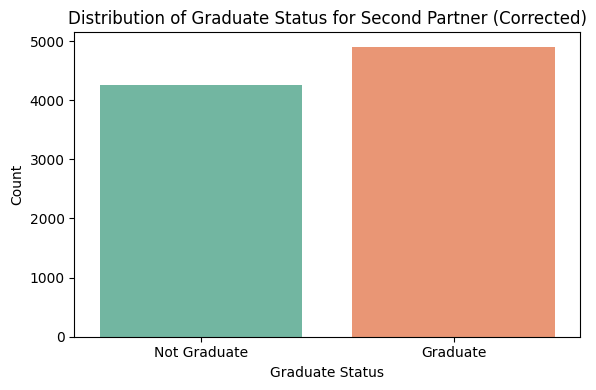

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=raw_df, x='second_partner_is_graduate', palette='Set2')
plt.xticks([0, 1], ['Not Graduate', 'Graduate'])
plt.title("Distribution of Graduate Status for Second Partner (Corrected)")
plt.xlabel("Graduate Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("graduate_status_distribution_corrected.png")
plt.show()

In [30]:
final_data = pd.read_excel("../Data/data_final.xlsx")

In [31]:
# Merge graduate data with final_data
graduate_info = raw_df[['filename', 'second_partner_is_graduate']]

data_final_with_graduate = pd.merge(
    final_data,
    graduate_info,
    on='filename',
    how='left'  
)

data_final_with_graduate.to_excel("data_final_with_graduate.xlsx", index=False)

In [ ]:
import shutil

shutil.move('../src/data_final_with_graduate.xlsx', '../Data/data_final_with_graduate.xlsx')

'../Data/data_final_with_graduate.xlsx'